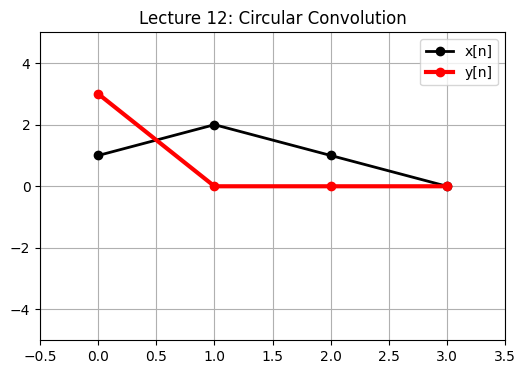

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Lecture 12: Circular Convolution (safe animation)
# Same pattern as Lecture 9
# -----------------------------

# Signals (length N)
x = np.array([1, 2, 1, 0])
h = np.array([1, -1, 2, 0])

N = len(x)

# Precompute circular convolution
y = np.zeros(N)
for n in range(N):
    for k in range(N):
        y[n] += x[k] * h[(n - k) % N]

# Setup plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xlim(-0.5, N - 0.5)
ax.set_ylim(-5, 5)
ax.grid(True)
ax.set_title("Lecture 12: Circular Convolution")

n = np.arange(N)

# Static input signal
ax.plot(n, x, 'ko-', lw=2, label="x[n]")

# Animated output signal
y_line, = ax.plot([], [], 'ro-', lw=3, label="y[n]")

ax.legend(loc="upper right")

# -----------------------------
# Animation update (Lecture 9 style)
# -----------------------------
def update(frame):
    # Reveal output sample by sample
    y_display = np.zeros(N)
    y_display[:frame+1] = y[:frame+1]

    y_line.set_data(n, y_display)
    return (y_line,)

anim = FuncAnimation(fig, update, frames=N, interval=700)

HTML(anim.to_jshtml())